In [56]:
import pandas as pd
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid", font_scale=1.5)

# Show current working directory
# print("Current Working Directory: ", os.getcwd())

# File paths
aws_path = 'C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/data4simon/AWS/aws_temperature.csv'

In [61]:

# Load data
aws_data = pd.read_csv(aws_path)
# print(aws_data.columns)

# # List all files in the directory "Data/2022"
# print(os.listdir('./Data/2022'))

### MODIS
# 2003
modd_data0 = pd.read_csv('./Data/2003/GEM_2003_AWS_MOD_DAY_LST_bit6lte0.csv')
mydd_data0 = pd.read_csv('./Data/2003/GEM_2003_AWS_MYD_DAY_LST_bit6lte0.csv')
modd_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MOD_DAY_LST_bit6lte1.csv')
modn_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MOD_NIGHT_LST_bit6lte1.csv')
mydd_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MYD_DAY_LST_bit6lte1.csv')
mydn_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MYD_NIGHT_LST_bit6lte1.csv')

# # 2022
# modd_data0 = pd.read_csv('./Data/2022/GEM_2022_AWS_MOD_DAY_LST_bit6lte0.csv')
# mydd_data0 = pd.read_csv('./Data/2022/GEM_2022_AWS_MYD_DAY_LST_bit6lte0.csv')
# modd_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MOD_DAY_LST_bit6lte1.csv')
# modn_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MOD_NIGHT_LST_bit6lte1.csv')
# mydd_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MYD_DAY_LST_bit6lte1.csv')
# mydn_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MYD_NIGHT_LST_bit6lte1.csv')


## 2024
## Read .xlsx files from the folder "Data" in the working directory
# modd_data0 = pd.read_excel('./Data/2024/GEM_AWS_MOD_DAY_LST_bit6lte0.xlsx')
# modd_data1 = pd.read_excel('./Data/2024/GEM_AWS_MOD_DAY_LST_bit6lte1.xlsx')
# modn_data1 = pd.read_excel('./Data/2024/GEM_AWS_MOD_NIGHT_LST_bit6lte1.xlsx')
# mydd_data0 = pd.read_excel('./Data/2024/GEM_AWS_MYD_DAY_LST_bit6lte0.xlsx')
# mydd_data1 = pd.read_excel('./Data/2024/GEM_AWS_MYD_DAY_LST_bit6lte1.xlsx')
# mydn_data1 = pd.read_excel('./Data/2024/GEM_AWS_MYD_NIGHT_LST_bit6lte1.xlsx')

### JAXA GCOM 
jaxa_a_data = pd.read_csv('./Data/JAXA_V3/GEM_2024_AWS_JAXA_A_LST.csv')
jaxa_d_data = pd.read_csv('./Data/JAXA_V3/GEM_2024_AWS_JAXA_D_LST.csv')


In [62]:
## Process AWS data (group by Date and station), if necessary 
aws_data['Date'] = pd.to_datetime(aws_data['Date']).dt.date
# aws_data['day'] = aws_data['Date']
# aws_data_mean = (
#     aws_data.groupby(['aws', 'day'], as_index=False)['temperature']
#             .mean()
#             .rename(columns={'temperature': 'mean_temperature', 'day': 'Date'})
# )


# Process modis data
modd_data0['Date'] = pd.to_datetime(modd_data0['system:time_start'], unit='ms').dt.date
modd_data0 = modd_data0.rename(columns={'id': 'aws', 'MOD_LST_Day':'est_temp'})
modd_data0['aws'] = modd_data0['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

modd_data1['Date'] = pd.to_datetime(modd_data1['system:time_start'], unit='ms').dt.date
modd_data1 = modd_data1.rename(columns={'id': 'aws', 'MOD_LST_Day':'est_temp'})
modd_data1['aws'] = modd_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

modn_data1['Date'] = pd.to_datetime(modn_data1['system:time_start'], unit='ms').dt.date
modn_data1 = modn_data1.rename(columns={'id': 'aws', 'MOD_LST_Night':'est_temp'})
modn_data1['aws'] = modn_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

mydd_data0['Date'] = pd.to_datetime(mydd_data0['system:time_start'], unit='ms').dt.date
mydd_data0 = mydd_data0.rename(columns={'id': 'aws', 'MYD_LST_Day':'est_temp'})
mydd_data0['aws'] = mydd_data0['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

mydd_data1['Date'] = pd.to_datetime(mydd_data1['system:time_start'], unit='ms').dt.date
mydd_data1 = mydd_data1.rename(columns={'id': 'aws', 'MYD_LST_Day':'est_temp'})
mydd_data1['aws'] = mydd_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

mydn_data1['Date'] = pd.to_datetime(mydn_data1['system:time_start'], unit='ms').dt.date
mydn_data1 = mydn_data1.rename(columns={'id': 'aws', 'MYD_LST_Night':'est_temp'})
mydn_data1['aws'] = mydn_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

jaxa_a_data['Date'] = pd.to_datetime(jaxa_a_data['system:time_start'], unit='ms').dt.date
jaxa_a_data = jaxa_a_data.rename(columns={'id': 'aws', 'JAXA_LST_AVE':'est_temp'})
jaxa_a_data['aws'] = jaxa_a_data['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

jaxa_d_data['Date'] = pd.to_datetime(jaxa_a_data['system:time_start'], unit='ms').dt.date
jaxa_d_data = jaxa_d_data.rename(columns={'id': 'aws', 'JAXA_LST_AVE':'est_temp'})
jaxa_d_data['aws'] = jaxa_d_data['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')





In [63]:
# print(modd_data0.dtypes, '\n')
# print(aws_data_mean.dtypes)
# print(type(aws_data['Date']))
# print(type(modd_data0['Date']))

# print(aws_data['aws'].unique())
# print(modd_data0['aws'].unique())


# Merge each of the datasets with AWS data using nearest time within 1 hour tolerance
df_modd0 = pd.merge(
    aws_data,
    modd_data0,
    on=['aws', 'Date'],
    how='inner'
)
df_modd0 = df_modd0.dropna()

df_modd1 = pd.merge(
    aws_data,
    modd_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_modd1 = df_modd1.dropna()

df_modn1 = pd.merge(
    aws_data,
    modn_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_modn1 = df_modn1.dropna()

df_mydd0 = pd.merge(
    aws_data,
    mydd_data0,
    on=['aws', 'Date'],
    how='inner'
)
df_mydd0 = df_mydd0.dropna()

df_mydd1 = pd.merge(
    aws_data,
    mydd_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_mydd1 = df_mydd1.dropna()

df_mydn1 = pd.merge(
    aws_data,
    mydn_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_mydn1 = df_mydn1.dropna()

df_jaxa_a = pd.merge(
    aws_data,
    jaxa_a_data,
    on=['aws', 'Date'],
    how='inner'
)
df_jaxa_a = df_jaxa_a.dropna()

df_jaxa_d = pd.merge(
    aws_data,
    jaxa_d_data,
    on=['aws', 'Date'],
    how='inner'
)
df_jaxa_d = df_jaxa_d.dropna()


In [66]:
print(len(df_modd0))
print(len(df_modd1))
print(len(df_modn1))
print(len(df_mydd0))
print(len(df_mydd1))
print(len(df_mydn1))

print('\nJAXA A: ', len(df_jaxa_a))
print('JAXA D: ', len(df_jaxa_d))

5826
14073
13275
5346
14510
13237

JAXA A:  529
JAXA D:  508


Dataset MOD_DAY_bit6=0
No. of observations (total df):  5826
Coefficients:  [0.79677382]
Intercept:  -2.95053843010706
R-squared:  0.9480198218517549 



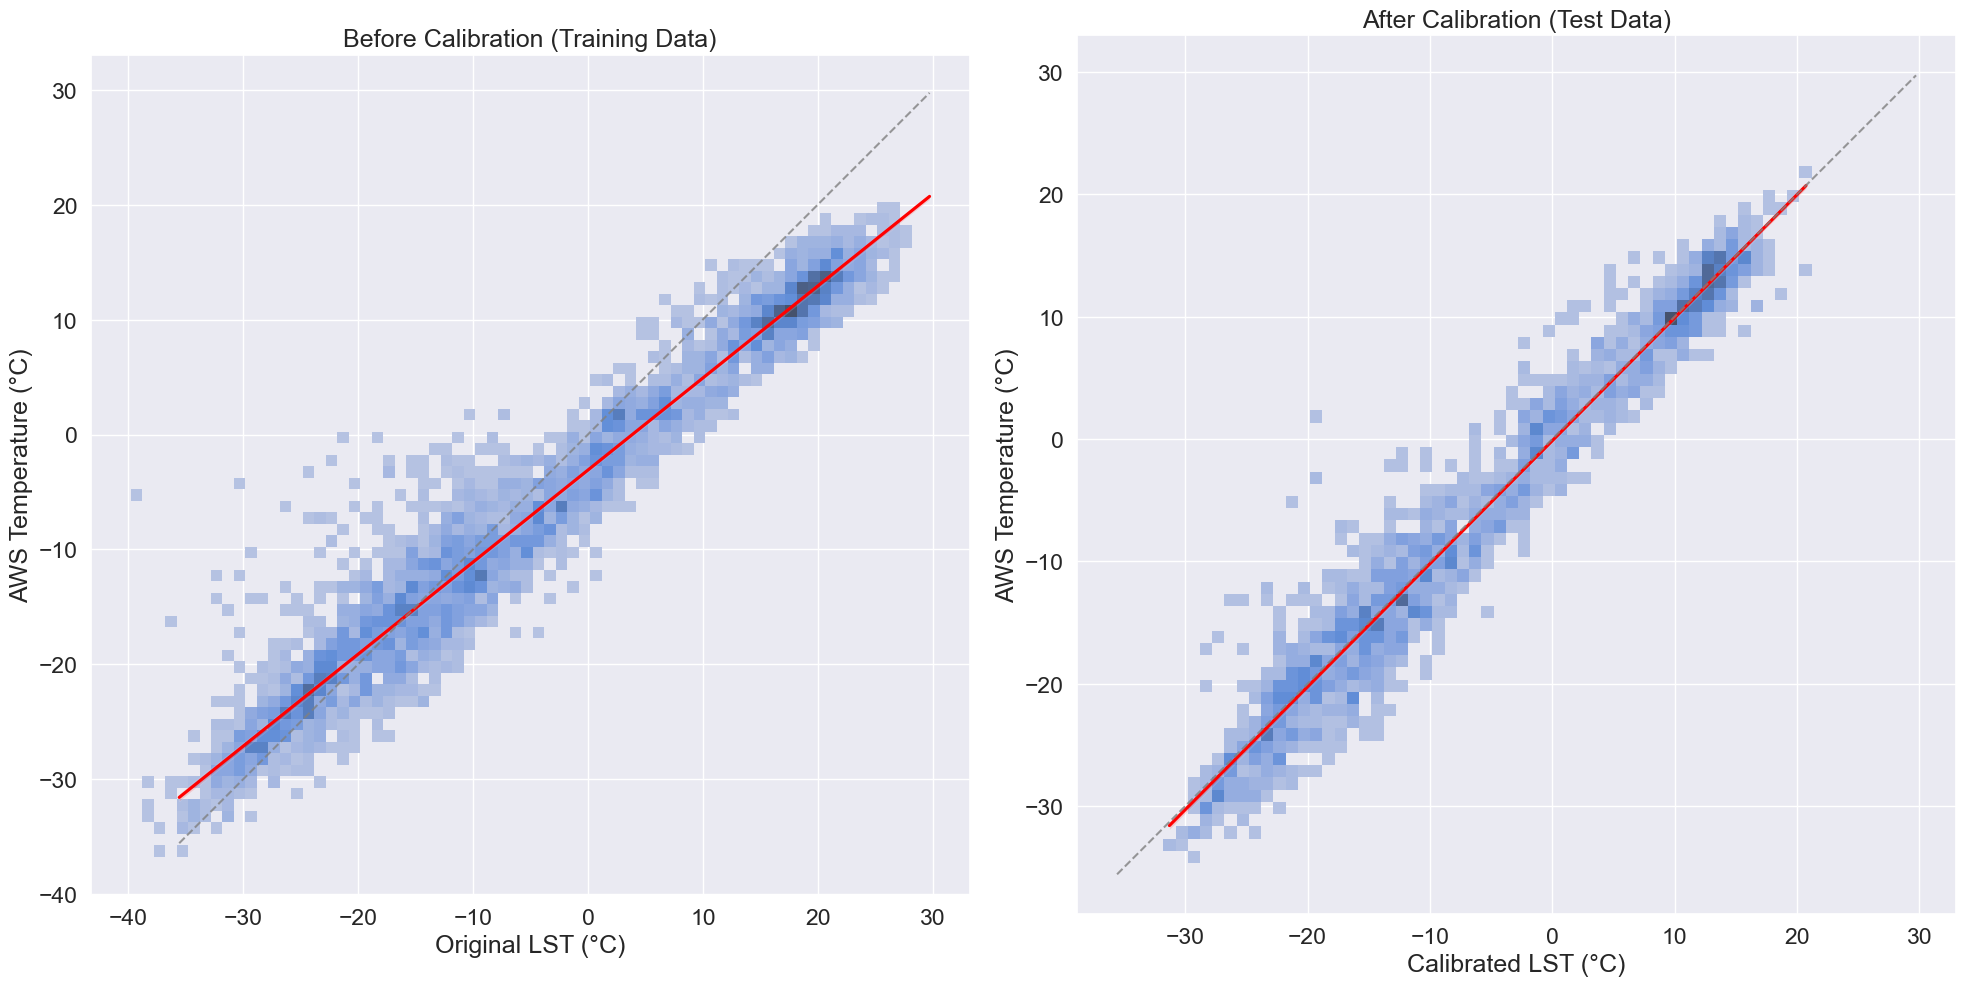

Dataset MOD_DAY_bit6=1
No. of observations (total df):  14073
Coefficients:  [0.75725494]
Intercept:  -1.4372568425392922
R-squared:  0.8876011021450736 



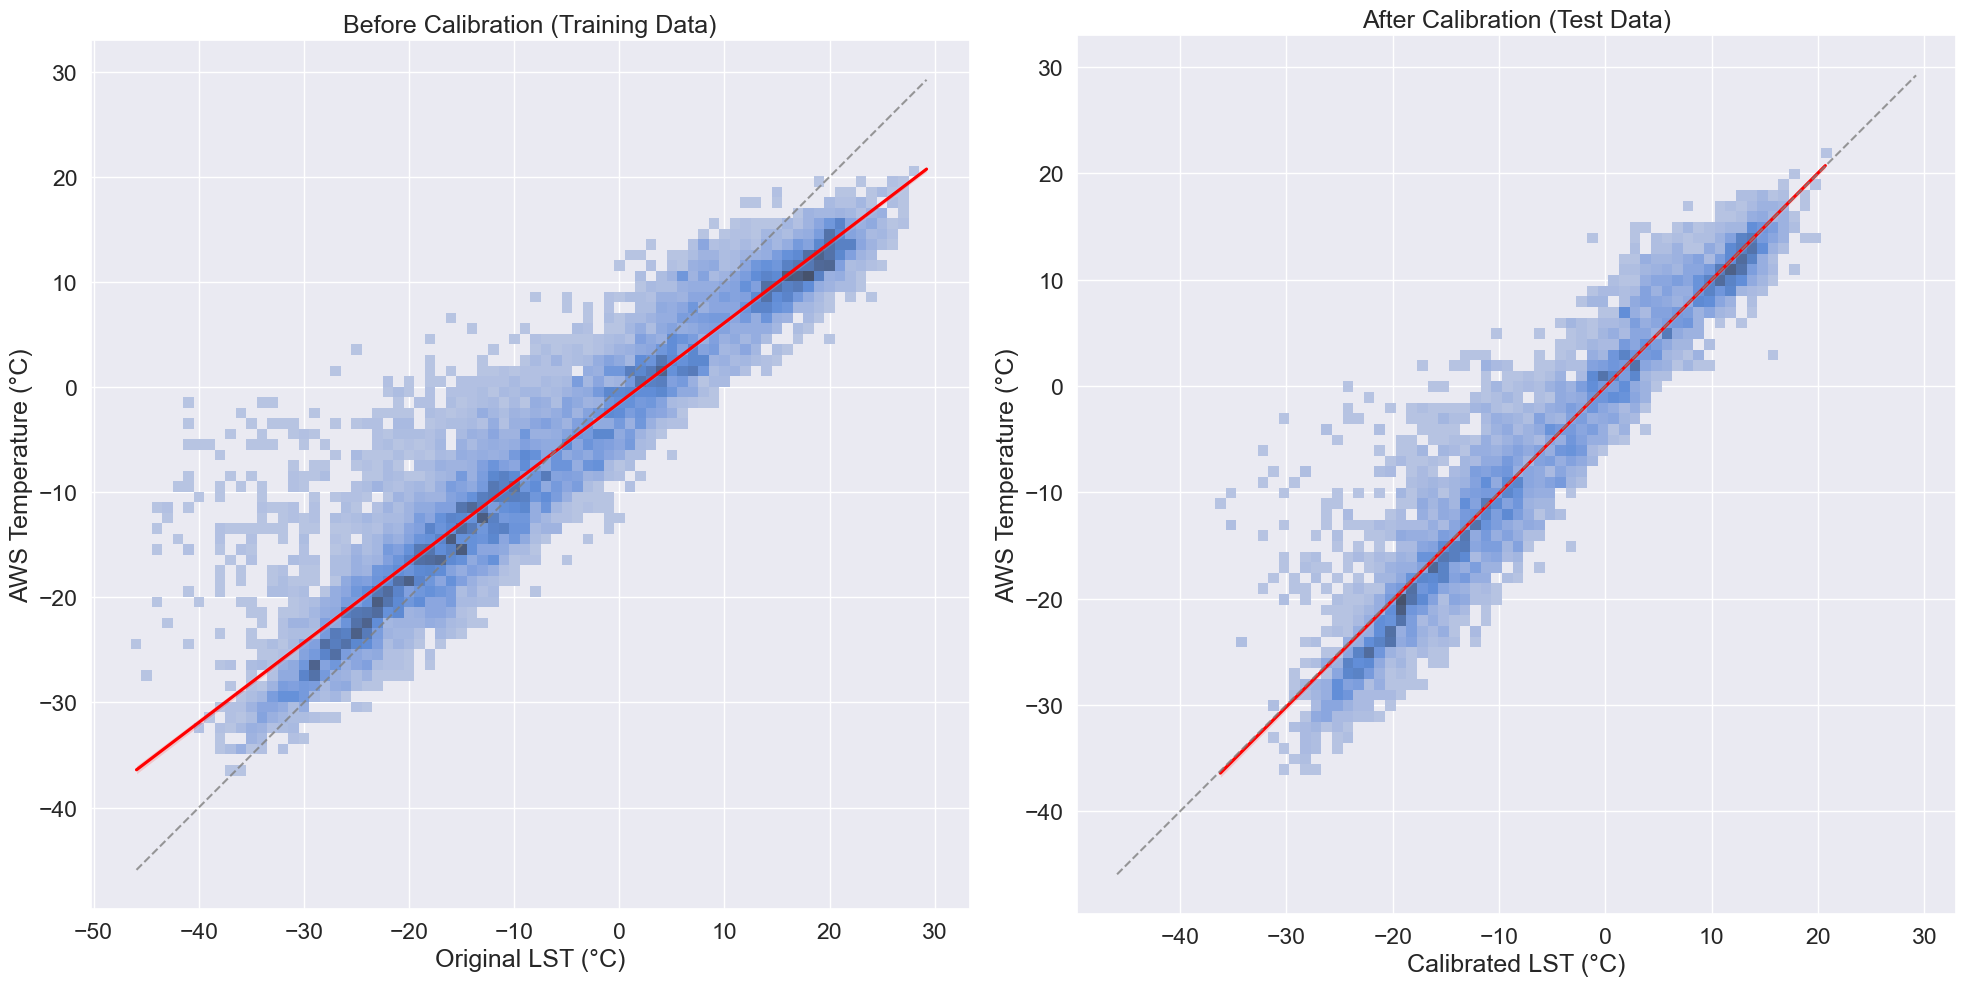

Dataset MOD_NIGHT_bit6=1
No. of observations (total df):  13275
Coefficients:  [0.93118777]
Intercept:  4.503017794575085
R-squared:  0.8724985785766484 



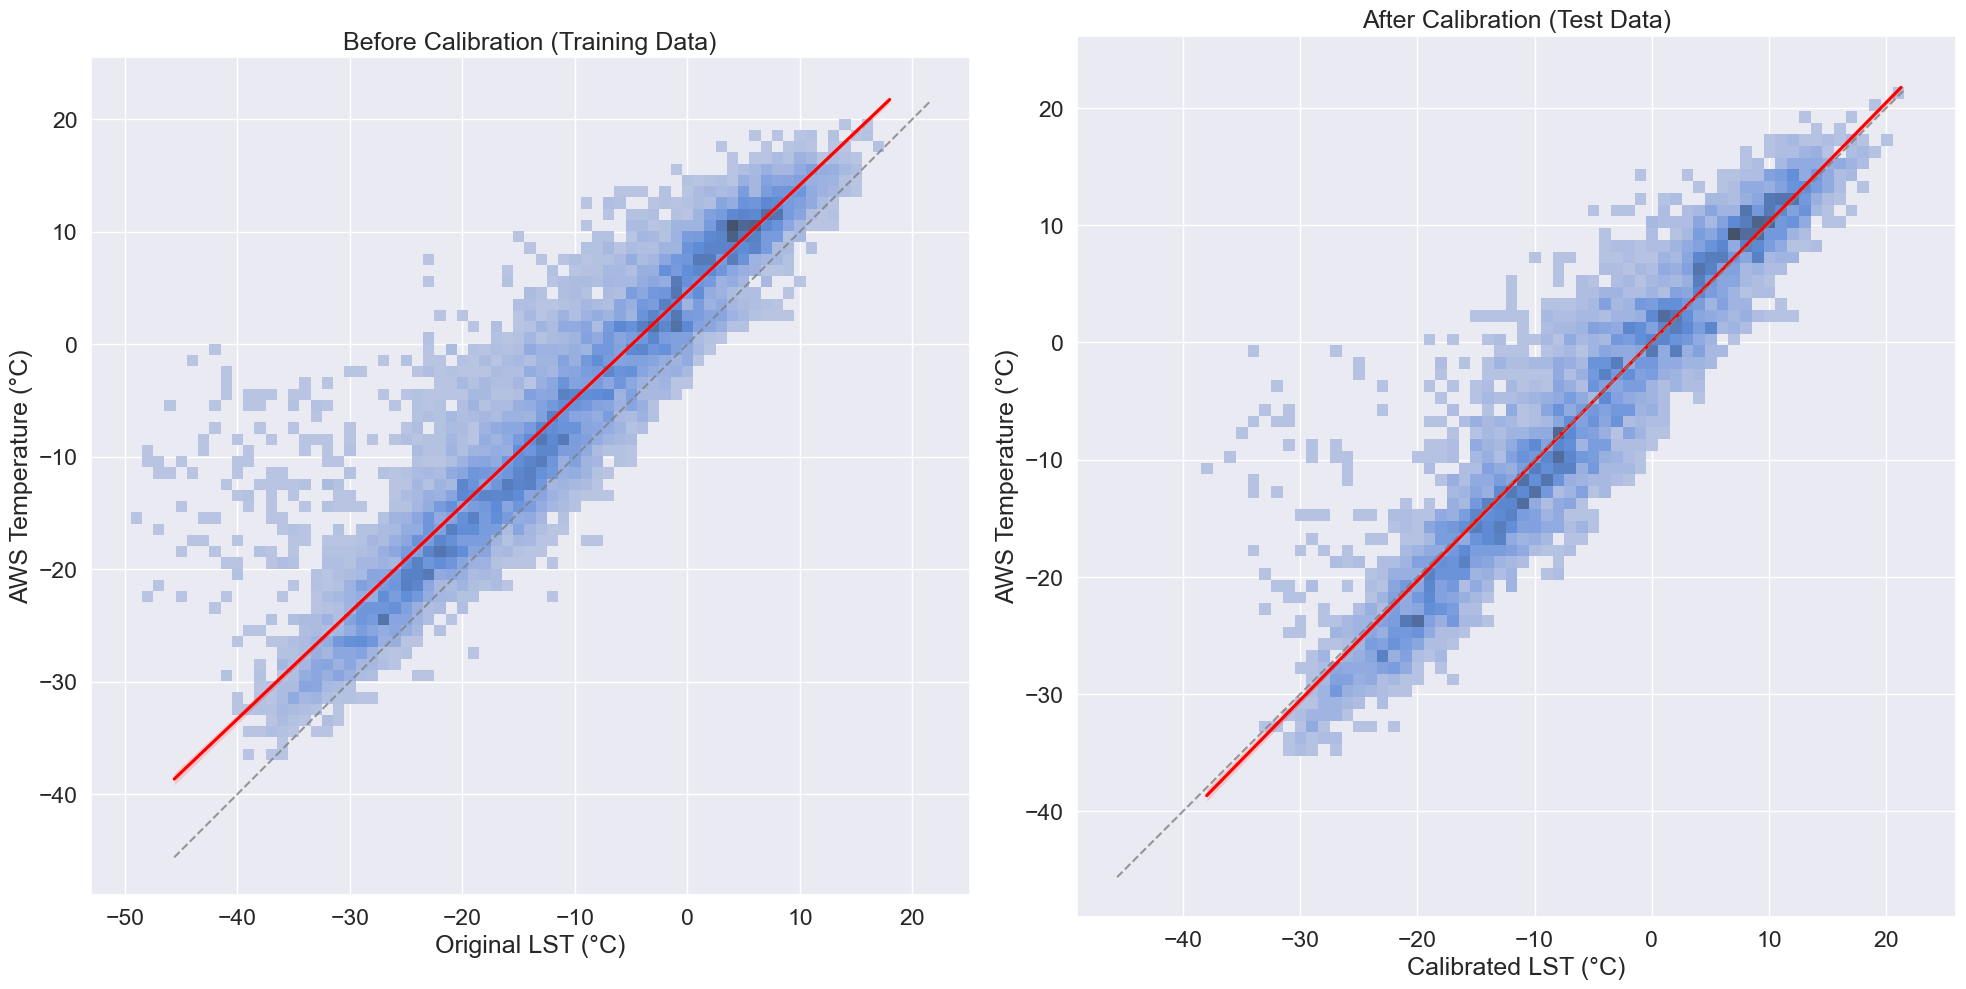

Dataset MYD_DAY_bit6=0
No. of observations (total df):  5346
Coefficients:  [0.80331546]
Intercept:  -3.1447668363821295
R-squared:  0.960569238114445 



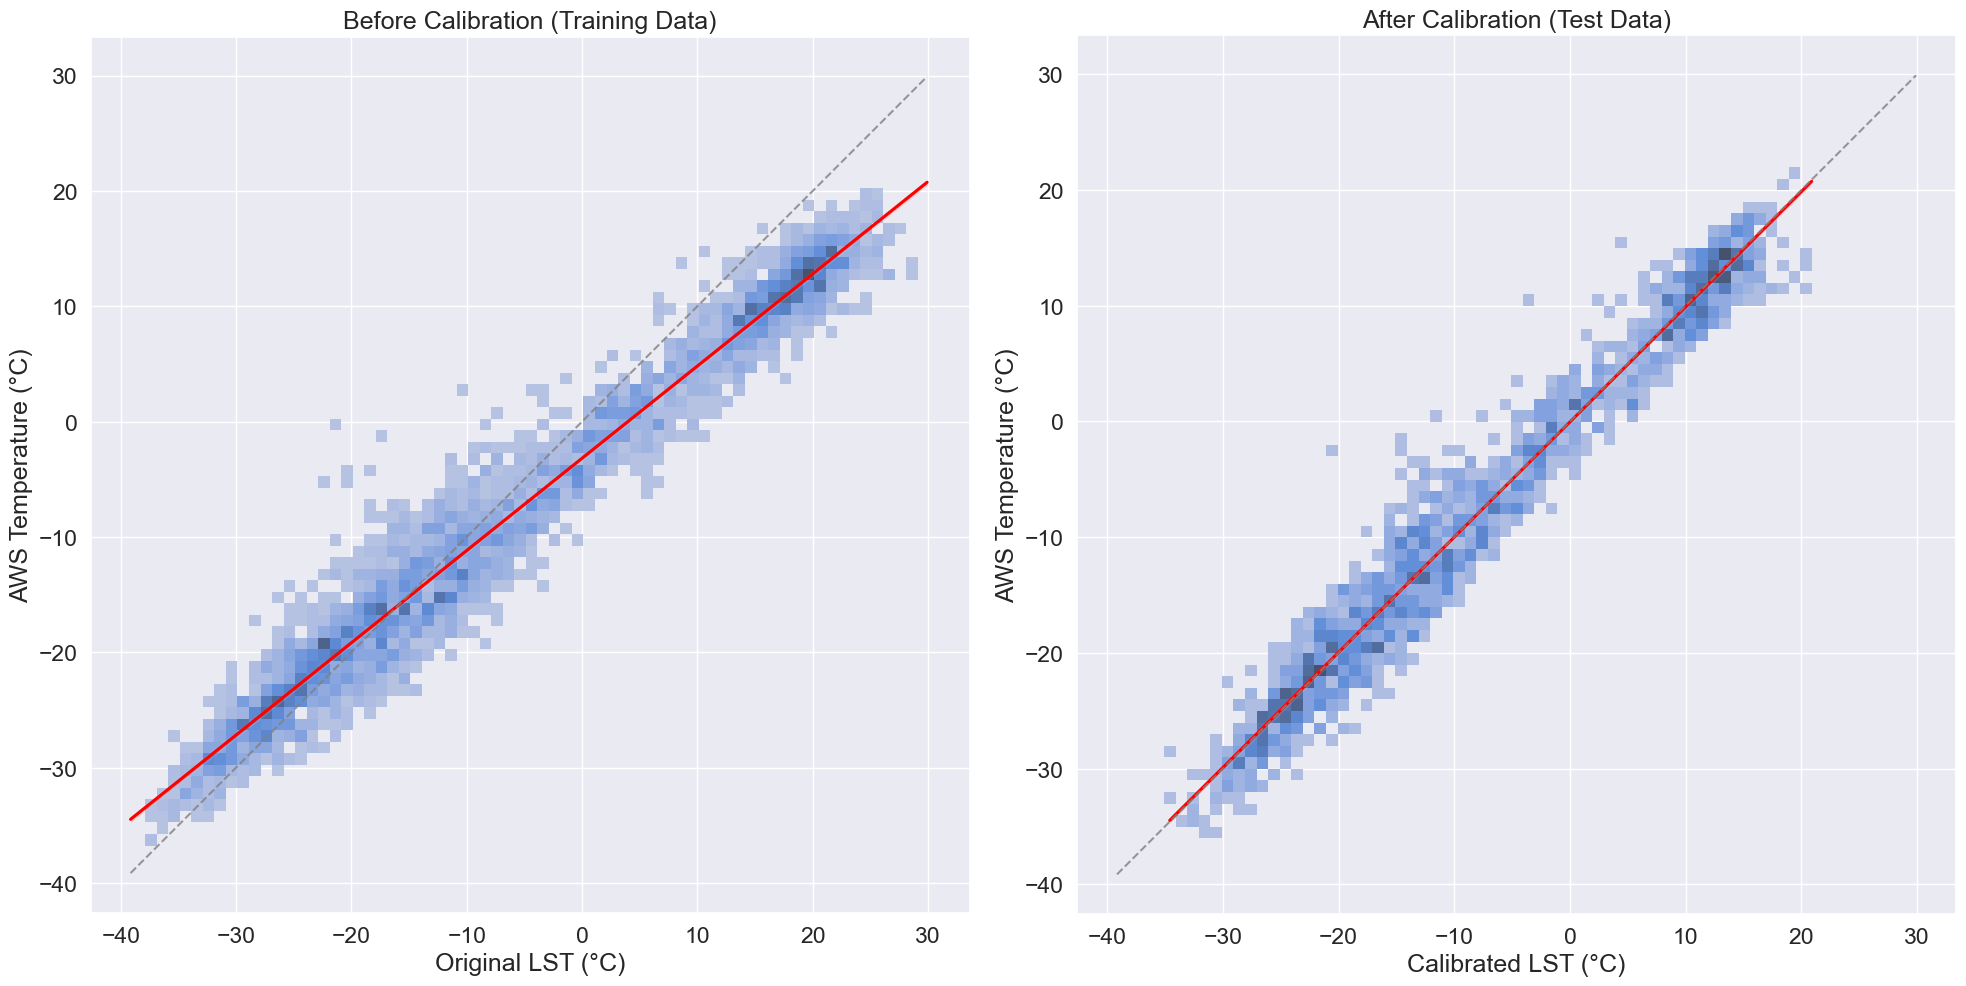

Dataset MYD_DAY_bit6=1
No. of observations (total df):  14510
Coefficients:  [0.77682864]
Intercept:  -1.5031668452946896
R-squared:  0.9051185899472419 



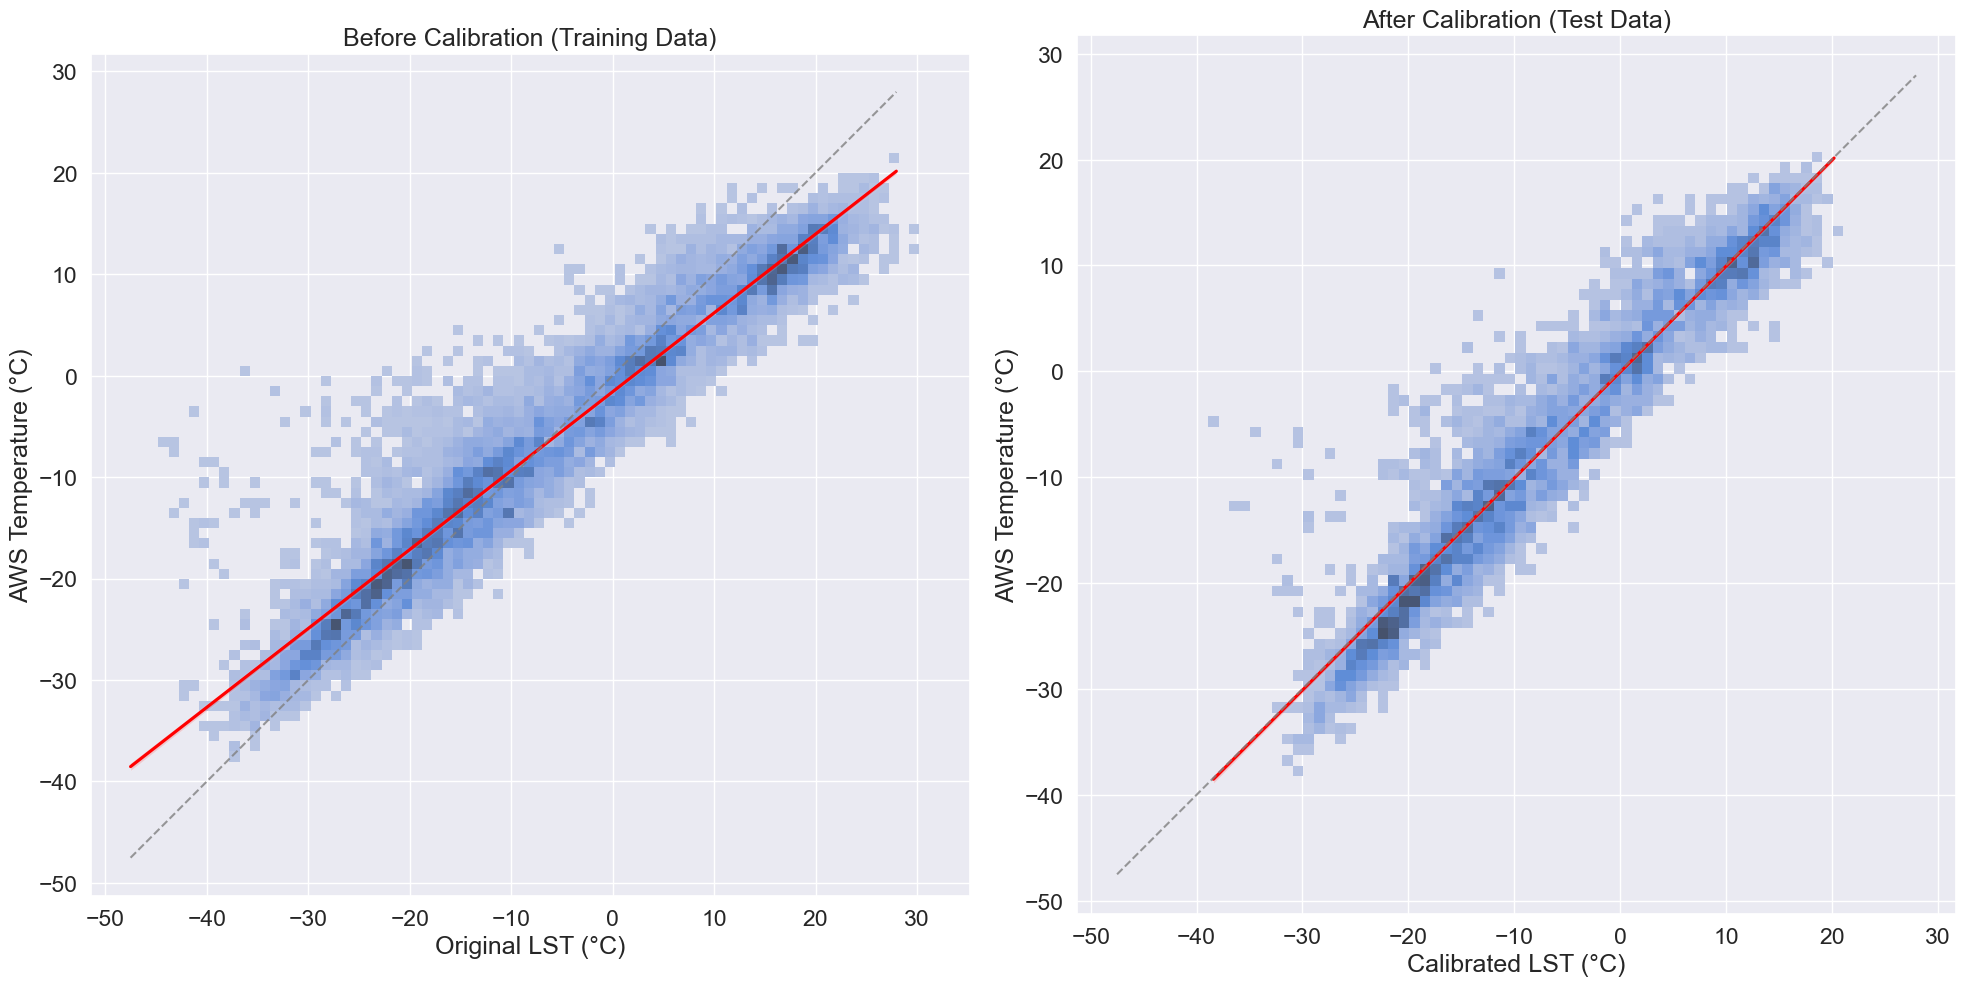

Dataset MYD_NIGHT_bit6=1
No. of observations (total df):  13237
Coefficients:  [0.9980887]
Intercept:  6.139988889555096
R-squared:  0.8428758274013696 



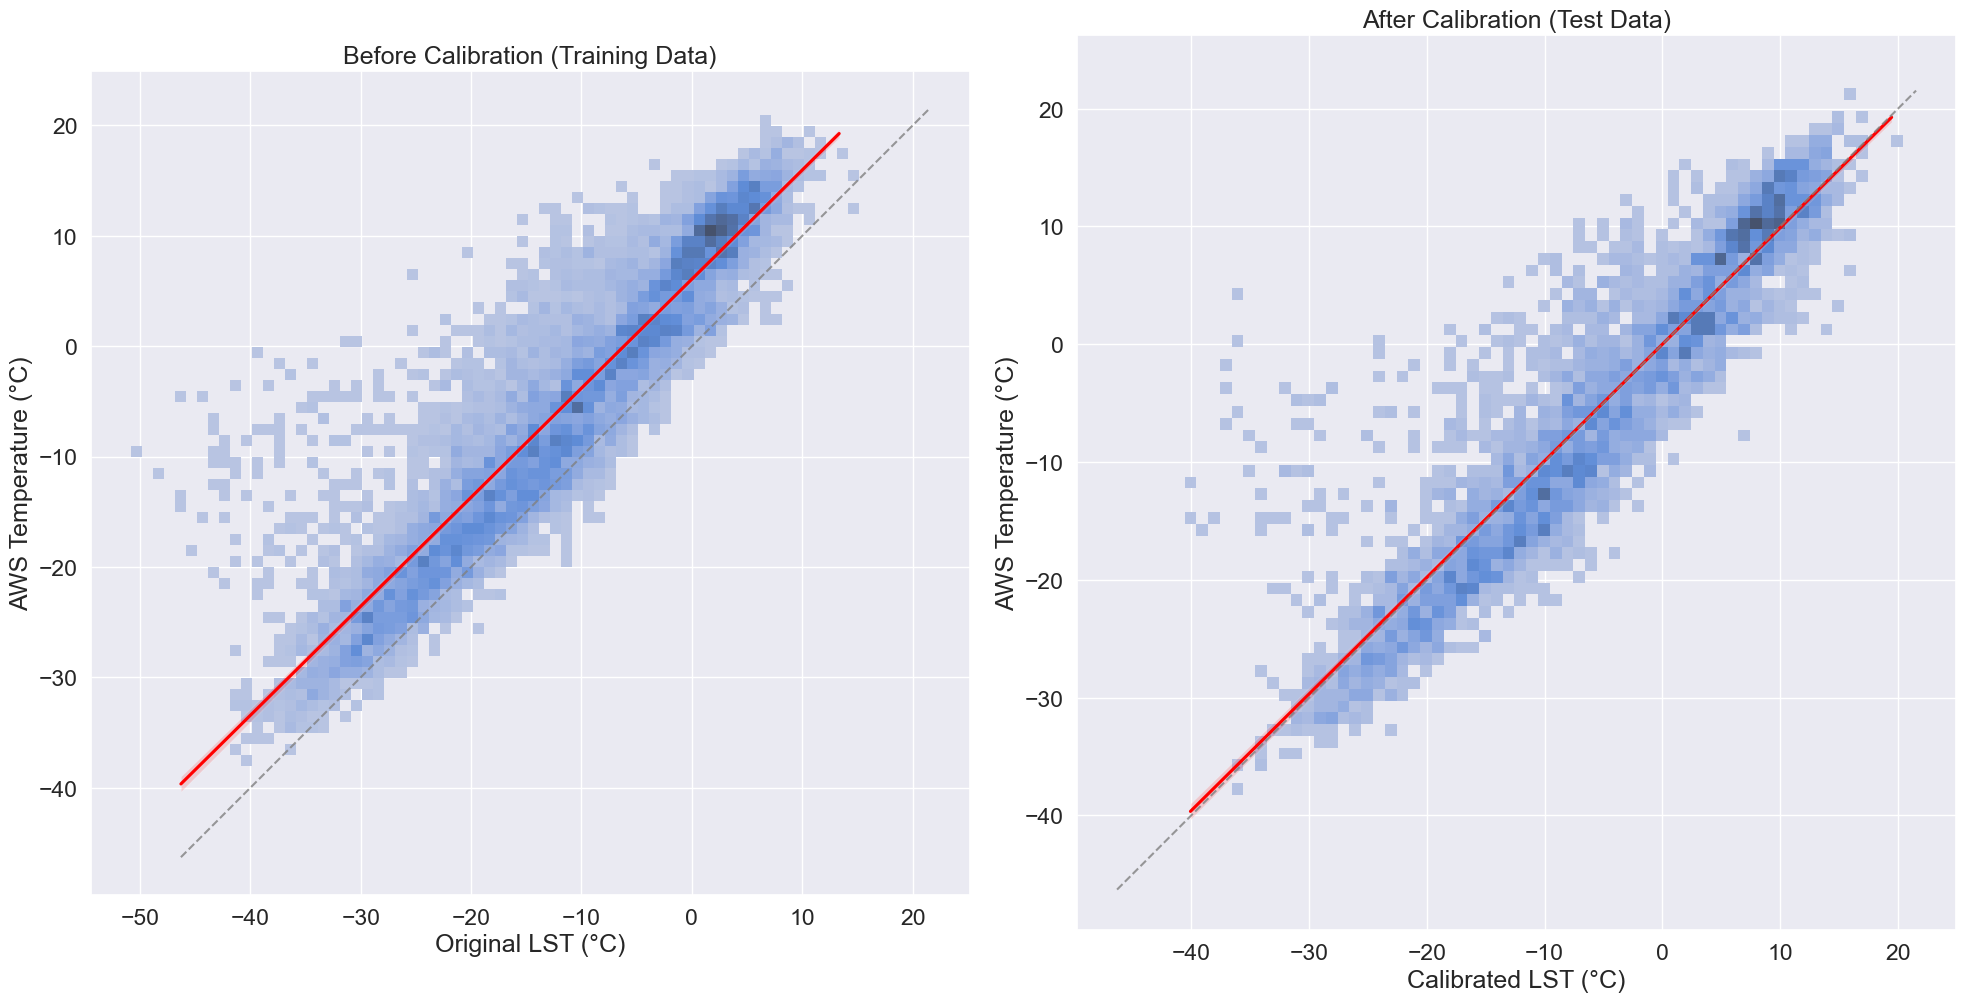

Dataset JAXA_A
No. of observations (total df):  529
Coefficients:  [0.94988846]
Intercept:  1.6628642447685544
R-squared:  0.5105935353958276 



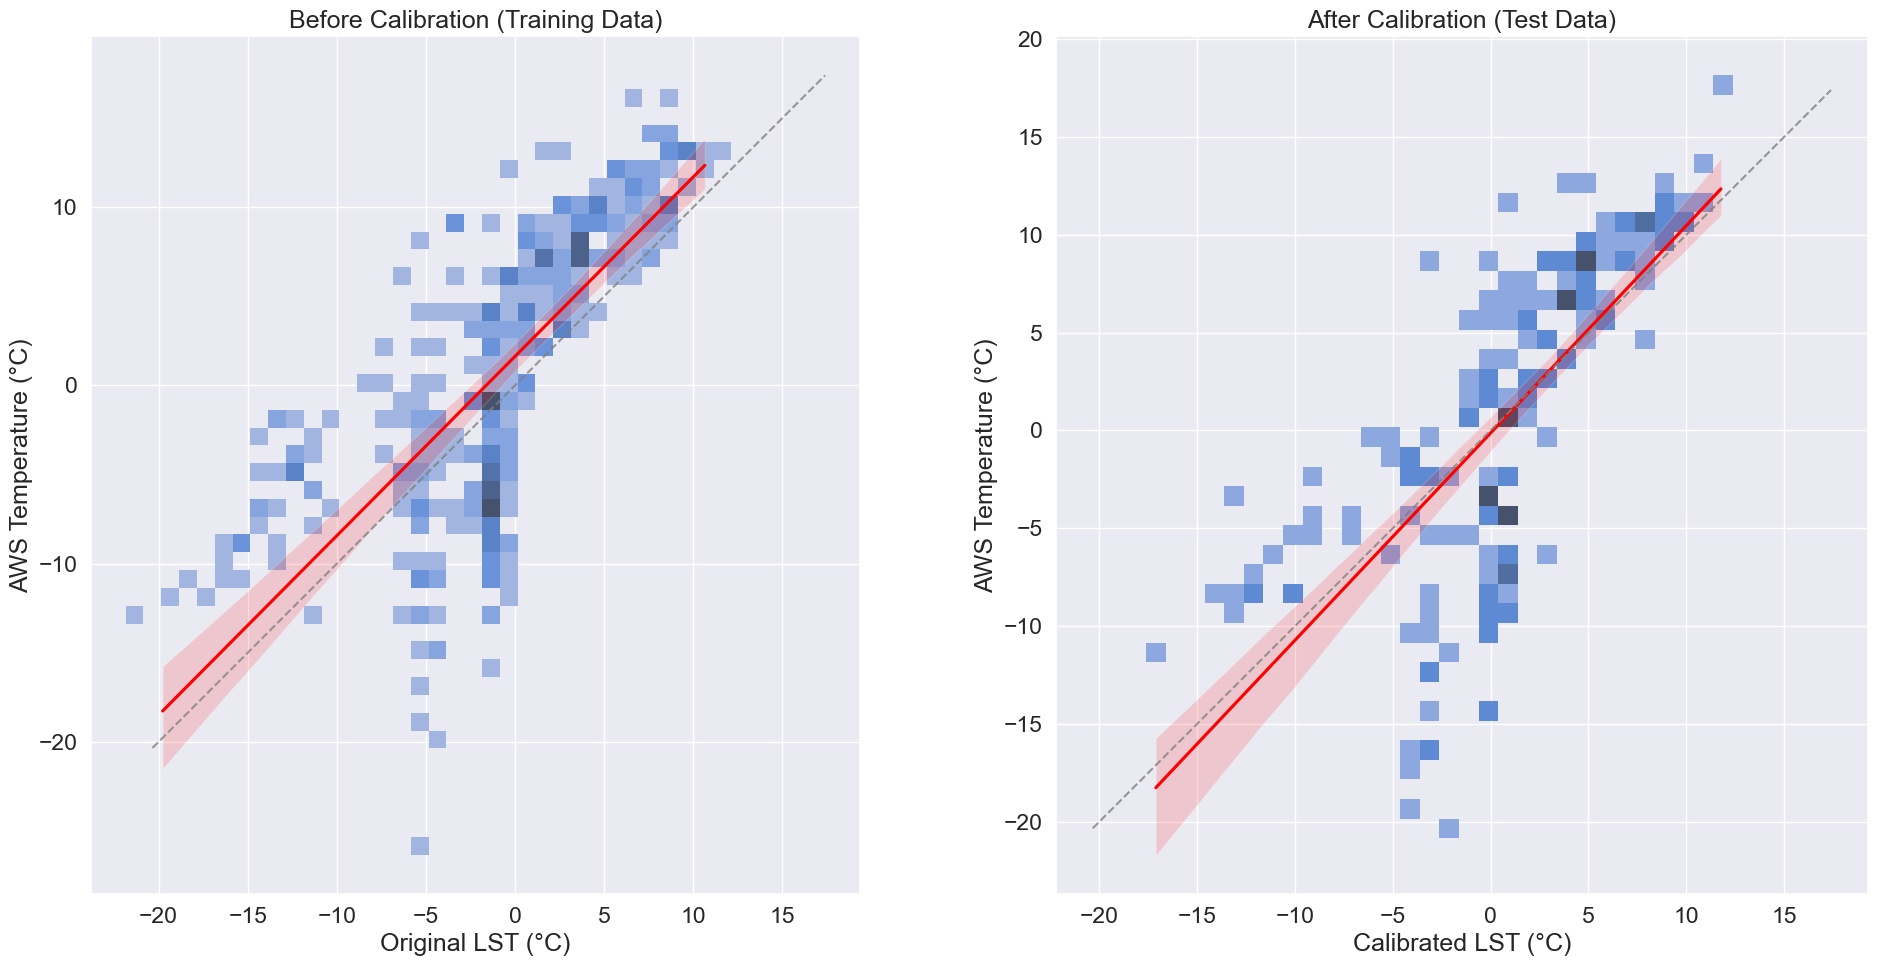

Dataset JAXA_D
No. of observations (total df):  508
Coefficients:  [0.14560033]
Intercept:  0.6892121284751597
R-squared:  0.05269561430746372 



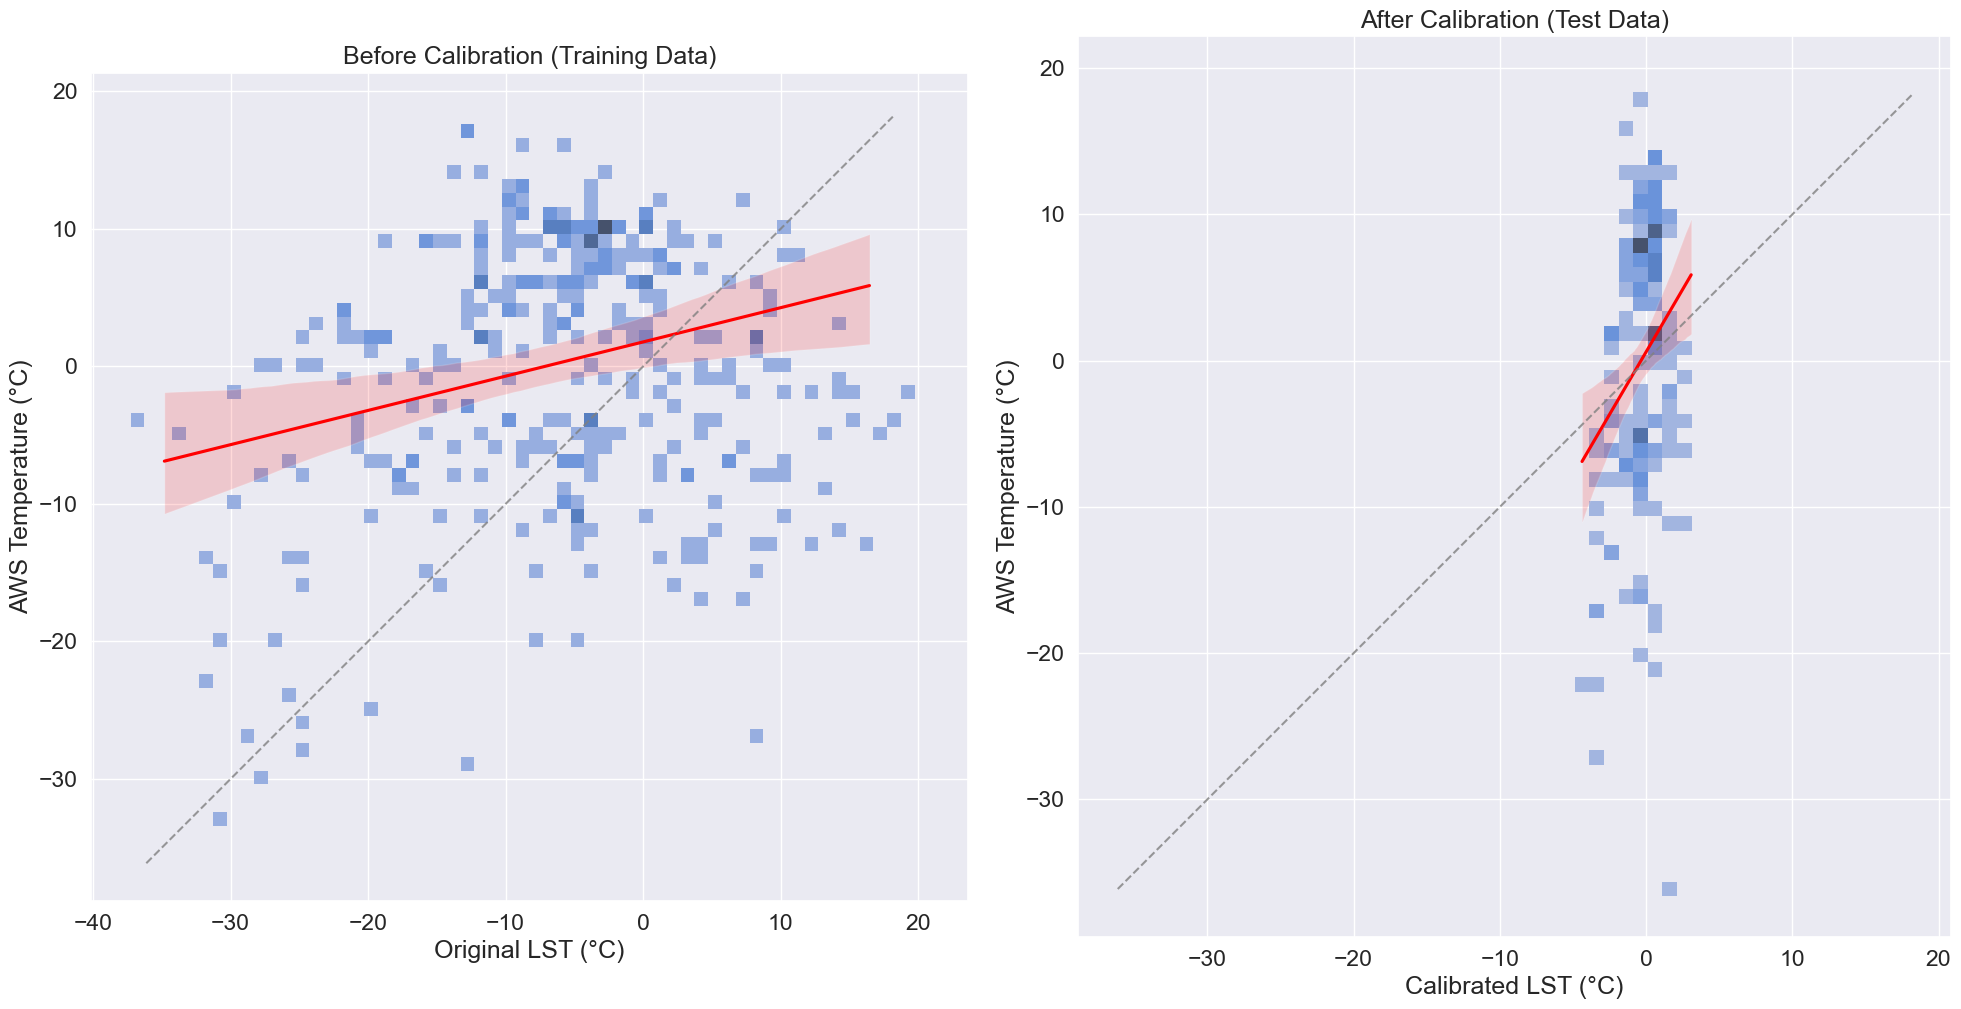

In [67]:
dfs = [df_modd0, df_modd1, df_modn1, df_mydd0, df_mydd1, df_mydn1, df_jaxa_a, df_jaxa_d]
labels = ["MOD_DAY_bit6=0", "MOD_DAY_bit6=1", "MOD_NIGHT_bit6=1", "MYD_DAY_bit6=0", "MYD_DAY_bit6=1", "MYD_NIGHT_bit6=1", "JAXA_A", "JAXA_D"]

def split_mod_viz(df):
    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['est_temp']], train_df['temperature'])
    temperature_pred = model.predict(test_df[['est_temp']])

    # # Calculate significance of the coefficients - Not working yet
    # p_values = []
    # for i in range(len(model.coef_)):
    #     _, p_value = stats.pearsonr(train_df['est_temp'], train_df['temperature'])
    #     p_values.append(p_value)

    # The coefficients
    print('No. of observations (total df): ', len(df))
    print('Coefficients: ', model.coef_)
    print('Intercept: ', model.intercept_)
    print('R-squared: ', model.score(test_df[['est_temp']], test_df['temperature']), '\n')

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_

    # Create comparison plot of original vs calibrated values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Add 1:1 reference line 
    min_val = min(test_df['est_temp'].min(), test_df['temperature'].min())
    max_val = max(test_df['est_temp'].max(), test_df['temperature'].max())

    # # SCATTER PLOTS
    # # Original est_temp plot
    # sns.scatterplot(ax=ax1, data=train_df, x='est_temp', y='temperature', alpha=0.5, hue='aws', palette='tab10')
    # sns.regplot(ax=ax1, data=test_df, x='est_temp', y='temperature', scatter=False, color='red')
    # ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    # ax1.set_xlabel('Original LST (°C)')
    # ax1.set_ylabel('AWS Temperature (°C)')
    # ax1.set_title('Before Calibration (Training Data)')
    # ax1.set_aspect('equal')

    # # Calibrated est_temp plot
    # sns.scatterplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', alpha=0.5, hue='aws', palette='tab10')
    # sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', scatter=False, color='red')
    # ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    # ax2.set_xlabel('Calibrated LST (°C)')
    # ax2.set_ylabel('AWS Temperature (°C)')
    # ax2.set_title('After Calibration (Test Data)')
    # ax2.set_aspect('equal')

    # plt.tight_layout()
    # plt.show()

    # 2d HISTOGRAM PLOTS
    # Original est_temp plot
    sns.histplot(ax=ax1, data=train_df, x='est_temp', y='temperature', bins=60, discrete=True)
    sns.regplot(ax=ax1, data=test_df, x='est_temp', y='temperature', scatter=False, color='red')
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax1.set_xlabel('Original LST (°C)')
    ax1.set_ylabel('AWS Temperature (°C)')
    ax1.set_title('Before Calibration (Training Data)')
    ax1.set_aspect('equal')

    # Calibrated est_temp plot
    sns.histplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', bins=60, discrete=True)
    sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', scatter=False, color='red')
    ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax2.set_xlabel('Calibrated LST (°C)')
    ax2.set_ylabel('AWS Temperature (°C)')
    ax2.set_title('After Calibration (Test Data)')
    ax2.set_aspect('equal')

    plt.tight_layout()
    plt.show()

for label, df in zip(labels, dfs):
    print(f"Dataset {label}")
    split_mod_viz(df)


# For large amounts of data, consider a 2d hist, kernel density or vaex plot
# https://seaborn.pydata.org/generated/seaborn.kdeplot.html
# https://seaborn.pydata.org/generated/seaborn.histplot.html
# https://vaex.io/docs/index.html


### Significance test of the coefficients 
Test whether the coefficients of bit6=0 and bit6=1 datasets are significantly different. If they are not significantly different, we might want to run the analysis with the larger dataset (bit6=0). 

In [7]:
import statsmodels.formula.api as smf

df_modd0['group'] = 'MOD_DAY_bit6=0'
df_modd1['group'] = 'MOD_DAY_bit6=1'
df_mydd0['group'] = 'MYD_DAY_bit6=0'
df_mydd1['group'] = 'MYD_DAY_bit6=1'

df_modd1010 = pd.concat([df_modd0, df_modd1])
df_mydd1010 = pd.concat([df_mydd0, df_mydd1])

print(df_modd1010.columns.unique())

sigcoef_mod = smf.ols("temperature ~ est_temp * group", data=df_modd1010).fit()
print(sigcoef_mod.summary())

sigcoef_myd = smf.ols("temperature ~ est_temp * group", data=df_mydd1010).fit()
print(sigcoef_myd.summary())

# The dummy variable "group" has a significant effect on the slope if the p-value of the interaction term (est_temp:group) is less than 0.05.

Index(['Date', 'temperature', 'aws', 'system:index', 'LST_Day_1km', 'est_temp',
       'MOD_QA_Day', 'QC_Day', 'date', 'system:time_start', 'timestamp',
       '.geo', 'group'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:            temperature   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                 6.069e+04
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:03:03   Log-Likelihood:                -56295.
No. Observations:               19899   AIC:                         1.126e+05
Df Residuals:                   19895   BIC:                         1.126e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
          

C:\Users\simon\AppData\Local\Temp\ipykernel_2508\3795880245.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_outlier['date'] = pd.to_datetime(mod_outlier['date'])
C:\Users\simon\AppData\Local\Temp\ipykernel_2508\3795880245.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_outlier['daynight'] = mod_outlier['date'].apply(lambda x: 'day' if 6 <= x.hour < 18 else 'night')
C:\Users\simon\AppData\Local\Temp\ipykernel_2508\3795880245.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy

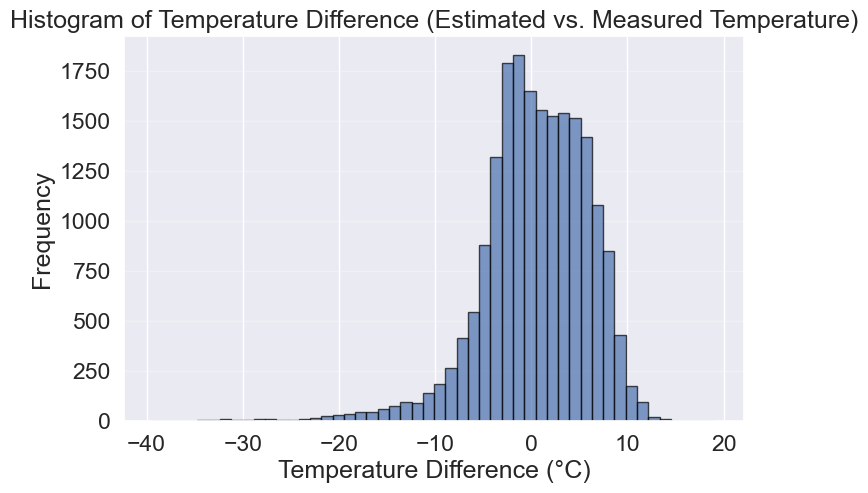

,aws,counts
1,Kobbefjord_M500,297
3,Zackenberg_M3,216
0,Disko_AWS2,196
2,Zackenberg_M2,185
4,Zackenberg_M4,145


In [11]:
# Take a closer look at the outliers. 

df_modd1010['temp_diff'] = (df_modd1010['est_temp'] - df_modd1010['temperature'])
mod_outlier = df_modd1010[df_modd1010['temp_diff'].abs() > 10]
mod_outlier['date'] = pd.to_datetime(mod_outlier['date'])
mod_outlier['daynight'] = mod_outlier['date'].apply(lambda x: 'day' if 6 <= x.hour < 18 else 'night')
mod_outlier['month'] = mod_outlier['date'].dt.month

plt.figure(figsize=(8,5))
plt.hist(df_modd1010["temp_diff"], bins=50, edgecolor='black', alpha=0.7)
plt.title("Histogram of Temperature Difference (Estimated vs. Measured Temperature)")
plt.xlabel("Temperature Difference (°C)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

mod_outlier.describe()

# # Create a scatter plot of df_modd1010 with calibrated LST vs temperature and add the points from mod_outlier in red
# fig, ax = plt.subplots()
# min_val = min(df_modd1010['est_temp'].min(), df_modd1010['temperature'].min())
# max_val = max(df_modd1010['est_temp'].max(), df_modd1010['temperature'].max())
# sns.scatterplot(data=df_modd1010, x='est_temp', y='temperature', alpha=0.5, color='black')
# sns.scatterplot(data=mod_outlier, x='est_temp', y='temperature', color='red', label= f'Outliers: {len(mod_outlier)}')
# sns.regplot(data=df_modd1010, x='est_temp', y='temperature', scatter=False, color='red')
# ax.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
# ax.set_xlabel('Calibrated LST (°C)')
# ax.set_ylabel('AWS Temperature (°C)')
# plt.tight_layout()
# plt.show()

# mod_outlier.describe(include='all')

mod_outlier.groupby('aws').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [9]:
# Loop through the datasets per sattelite, then evt. merge. 

# Apply calibration to the entire dataset
df['ST_B10_calibrated'] = df['ST_B10'] * model.coef_[0] + model.intercept_

# Group data by 'aws'
grouped = df.groupby('aws')

# Create a figure and a set of subplots
fig, axes = plt.subplots(len(grouped), 2, figsize=(20, 10*len(grouped)))

# Iterate over each group (each AWS)
for i, (aws_name, aws_data) in enumerate(grouped):
    # Add 1:1 reference line 
    min_val = min(aws_data['ST_B10'].min(), aws_data['temperature'].min())
    max_val = max(aws_data['ST_B10'].max(), aws_data['temperature'].max())

    # Original ST_B10 plot
    sns.scatterplot(ax=axes[i, 0], data=aws_data, x='ST_B10', y='temperature', alpha=0.5)
    sns.regplot(ax=axes[i, 0], data=aws_data, x='ST_B10', y='temperature', scatter=False, color='red')
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    axes[i, 0].set_xlabel('Original Landsat LST (°C)')
    axes[i, 0].set_ylabel('AWS Temperature (°C)')
    axes[i, 0].set_title(f'Before Calibration - AWS: {aws_name}')
    axes[i, 0].set_aspect('equal')

    # Calibrated ST_B10 plot
    sns.scatterplot(ax=axes[i, 1], data=aws_data, x='ST_B10_calibrated', y='temperature', alpha=0.5)
    sns.regplot(ax=axes[i, 1], data=aws_data, x='ST_B10_calibrated', y='temperature', scatter=False, color='red')
    axes[i, 1].plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    axes[i, 1].set_xlabel('Calibrated Landsat LST (°C)')
    axes[i, 1].set_ylabel('AWS Temperature (°C)')
    axes[i, 1].set_title(f'After Calibration - AWS: {aws_name}')
    axes[i, 1].set_aspect('equal')

plt.tight_layout()
plt.show()
# %%
# Save calibration model parameters to a file
model_params = {
    'coefficient': model.coef_[0],
    'intercept': model.intercept_,
    'r_squared': model.score(test_df[['ST_B10']], test_df['temperature'])
}

pd.DataFrame([model_params]).to_csv('landsat_calibration_parameters.txt', index=False)
print("\nCalibration model parameters saved to 'landsat_calibration_parameters.txt'")


KeyError: 'ST_B10'